# Oxford-IIIT Pet Breed Classification (CNN vs ResNet18)

This notebook explores image classification on the **Oxford-IIIT Pet dataset**, which contains **37 different cat and dog breeds**. The goal is to build and compare two deep learning approaches for breed recognition.

First, a **custom Convolutional Neural Network (CNN)** is trained from scratch to establish a baseline model. Then, a **transfer learning approach using a pretrained ResNet18** model is implemented to evaluate the benefits of pretrained feature extractors on a relatively small dataset.

The project focuses on:

* Building a **robust PyTorch data pipeline** with safe image loading and preprocessing
* Training a **custom CNN architecture from scratch**
* Applying **transfer learning with ResNet18**
* Comparing model performance using training and validation metrics
* Visualizing predictions to qualitatively evaluate model behavior

The results highlight the significant performance difference between training a model from scratch and leveraging pretrained deep networks for image classification tasks.


In [ ]:
import torch
import torchvision
from torchvision import transforms

In [ ]:
import os
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.datasets import OxfordIIITPet

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
#config
class CFG:
    DATA_ROOT   = "./data"
    BATCH_SIZE  = 32
    NUM_WORKERS = 2
    IMG_SIZE    = 224
    NUM_CLASSES = 37
    EPOCHS      = 10
    LR          = 1e-3
    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
    SEED        = 42

In [ ]:
class SafeImageDataset(Dataset):
    """
    Celal's error-free image dataset template.
    - Handles corrupted images (PIL verify)
    - Handles tiny images (min_size)
    - Converts non-RGB to RGB (optional)
    - Logs errors instead of crashing
    - Can skip bad samples by moving to next index (wrap-around)
    """

    def __init__(
        self,
        samples: List[Tuple[str, int]],     # [(img_path, label), ...]
        transform=None,
        min_size: int = 32,
        force_rgb: bool = True,
        verify_image: bool = True,
        max_skip_attempts: int = 20,
        log_warnings: bool = False,
    ):
        self.samples           = samples
        self.transform         = transform
        self.min_size          = min_size
        self.force_rgb         = force_rgb
        self.verify_image      = verify_image
        self.max_skip_attempts = max_skip_attempts
        self.log_warnings      = log_warnings
        self.error_log: List[Dict[str, Any]] = []

        if len(self.samples) == 0:
            raise ValueError("SafeImageDataset: 'samples' is empty. Check your paths/labels.")

    def __len__(self):
        return len(self.samples)

    def _open_and_check(self, img_path: str) -> Image.Image:
        img = Image.open(img_path)

        if self.verify_image:
            img.verify()
            img = Image.open(img_path)          # reopen after verify

        w, h = img.size
        if w < self.min_size or h < self.min_size:
            raise ValueError(f"Image too small: {img.size}")

        if self.force_rgb and img.mode != "RGB":
            img = img.convert("RGB")

        return img

    def __getitem__(self, idx: int):
        attempts  = 0
        start_idx = idx

        while attempts <= self.max_skip_attempts:
            img_path, label = self.samples[idx]

            try:
                img = self._open_and_check(img_path)

                if self.transform is not None:
                    img = self.transform(img)

                return img, label

            except Exception as e:
                self.error_log.append({
                    "index":       idx,
                    "start_index": start_idx,
                    "error":       str(e),
                    "path":        img_path,
                })

                if self.log_warnings:
                    print(f"Warning: skipping bad image idx={idx} path='{img_path}' err={e}")

                attempts += 1
                idx = (idx + 1) % len(self.samples)

        raise RuntimeError(
            f"SafeImageDataset: too many bad samples in a row (>{self.max_skip_attempts}). "
            f"Dataset may be heavily corrupted. Last start_idx={start_idx}"
        )

    def get_error_summary(self, top_k: int = 5) -> Dict[str, Any]:
        """Return a quick summary (use after training)."""
        if not self.error_log:
            return {"count": 0, "message": "No errors encountered - dataset looks clean!"}

        counts = {}
        for item in self.error_log:
            msg = item["error"]
            counts[msg] = counts.get(msg, 0) + 1

        top_errors = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return {
            "count":       len(self.error_log),
            "top_errors":  top_errors,
            "sample_logs": self.error_log[:top_k],
        }


In [ ]:
# def get_transforms(split: str = "train"):
#     mean = [0.485, 0.456, 0.406]
#     std  = [0.229, 0.224, 0.225]

#     if split == "train":
#         return transforms.Compose([
#             transforms.RandomResizedCrop(CFG.IMG_SIZE),
#             transforms.RandomHorizontalFlip(),
#             transforms.ColorJitter(0.2, 0.2, 0.2),
#             transforms.ToTensor(),
#             transforms.Normalize(mean, std),
#         ])
#     else:
#         return transforms.Compose([
#             transforms.Resize(256),
#             transforms.CenterCrop(CFG.IMG_SIZE),
#             transforms.ToTensor(),
#             transforms.Normalize(mean, std),
#         ])

def get_transforms(split: str = "train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

In [ ]:
from torchvision.datasets import OxfordIIITPet

raw_train = OxfordIIITPet(
    root = CFG.DATA_ROOT,
    split = "trainval",
    target_types = "category",
    download = True,
)

raw_test = OxfordIIITPet(
    root = CFG.DATA_ROOT,
    split = "test",
    target_types= "category",
    download = True
)

In [ ]:
def build_oxford_samples(ds):
    samples = []
    for img_path, label in zip(ds._images, ds._labels):
        samples.append((str(img_path), int(label)))
    return samples

In [ ]:
train_samples = build_oxford_samples(raw_train)
test_samples  = build_oxford_samples(raw_test)

print("train samples:", len(train_samples))
print("test samples:", len(test_samples))
print(train_samples[0])

train samples: 3680
test samples: 3669
('data/oxford-iiit-pet/images/Abyssinian_100.jpg', 0)


In [ ]:
train_ds = SafeImageDataset(
    samples=train_samples,
    transform=get_transforms("train"),
    min_size=32,
    force_rgb=True,
    verify_image=True,
    max_skip_attempts=20,
    log_warnings=False
)

test_ds = SafeImageDataset(
    samples=test_samples,
    transform=get_transforms("test"),
    min_size=32,
    force_rgb=True,
    verify_image=True,
    max_skip_attempts=20,
    log_warnings=False
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

In [ ]:
x,y = next(iter(train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("labels:", y[:10])

x shape: torch.Size([32, 3, 224, 224])
y shape: torch.Size([32])
labels: tensor([25, 16, 35,  9, 31, 12, 17, 14,  2, 17])


In [ ]:
all_labels = [label for _, label in train_samples]
print("num classes:", len(set(all_labels)))
print("min label:", min(all_labels))
print("max label:", max(all_labels))

num classes: 37
min label: 0
max label: 36


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PetCNN(nn.Module):
    def __init__(self, num_classes=CFG.NUM_CLASSES):
        super().__init__()

        # block1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # block2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # block3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # block4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # classifier
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.gap(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
model = PetCNN().to(CFG.DEVICE)

x,y = next(iter(train_loader))
x = x.to(CFG.DEVICE)

out = model(x)
print("output shape:", out.shape)

output shape: torch.Size([32, 37])


In [ ]:
model = PetCNN().to(CFG.DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG.LR
)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0 ,0 ,0

    for x, y in loader:
      x, y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)

      optimizer.zero_grad()
      logits = model(x)
      loss = criterion(logits, y)
      loss.backward()
      optimizer.step()

      preds = logits.argmax(dim=1)
      total_loss += loss.item() * x.size(0)
      total_correct += (preds == y).sum().item()
      total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0 ,0 ,0

    for x, y in loader:
      x, y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)

      logits = model(x)
      loss = criterion(logits, y)

      preds = logits.argmax(dim=1)
      total_loss += loss.item() * x.size(0)
      total_correct += (preds == y).sum().item()
      total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
import random
from typing import List, Optional

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms


def show_sample_predictions(
    model: nn.Module,
    dataset,
    class_names: List[str],
    n: int = 16,
    cols: int = 4,
    save_path: Optional[str] = "sample_predictions.png",
):
    """
    Random n samples -> forward pass -> grid plot
    Correct predictions: green border
    Wrong predictions  : red border
    """

    model.eval()

    inv_norm = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )

    n = min(n, len(dataset))
    indices = random.sample(range(len(dataset)), n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))

    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    fig.suptitle("Sample Predictions\n✅ Correct  ❌ Wrong", fontsize=14, fontweight="bold")

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_tensor, true_label = dataset[idx]

            x = img_tensor.unsqueeze(0).to(CFG.DEVICE)
            logits = model(x)

            probs = torch.softmax(logits, dim=1)
            pred_label = probs.argmax(dim=1).item()
            confidence = probs.max(dim=1).values.item()

            img_display = inv_norm(img_tensor.cpu()).permute(1, 2, 0).clamp(0, 1).numpy()

            correct = pred_label == true_label
            color = "green" if correct else "red"
            symbol = "✅" if correct else "❌"

            ax.imshow(img_display)
            ax.set_title(
                f"{symbol} Pred: {class_names[pred_label]}\n"
                f"True: {class_names[true_label]} | Conf: {confidence:.1%}",
                fontsize=8,
                color=color,
            )

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

            ax.set_xticks([])
            ax.set_yticks([])

    for ax in axes[len(indices):]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Viz] Saved -> {save_path}")

    plt.show()

In [ ]:
class_names = raw_train.classes
print(class_names[:5])

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = -1.0

for epoch in range(1, CFG.EPOCHS + 1):
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
  val_loss, val_acc = evaluate(model, test_loader, criterion)

  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), "best_petcnn.pth")

  print(
      f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
        f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f} | "
        f"best val acc: {best_val_acc:.4f}"
  )

Epoch 01/10 | train loss: 3.6036 | train acc: 0.0416 | val loss: 3.5555 | val acc: 0.0406 | best val acc: 0.0406
Epoch 02/10 | train loss: 3.5298 | train acc: 0.0514 | val loss: 3.4957 | val acc: 0.0662 | best val acc: 0.0662
Epoch 03/10 | train loss: 3.4584 | train acc: 0.0720 | val loss: 3.4362 | val acc: 0.0752 | best val acc: 0.0752
Epoch 04/10 | train loss: 3.4133 | train acc: 0.0750 | val loss: 3.4103 | val acc: 0.0662 | best val acc: 0.0752
Epoch 05/10 | train loss: 3.3544 | train acc: 0.0916 | val loss: 3.3544 | val acc: 0.0815 | best val acc: 0.0815
Epoch 06/10 | train loss: 3.2997 | train acc: 0.0984 | val loss: 3.3493 | val acc: 0.0872 | best val acc: 0.0872
Epoch 07/10 | train loss: 3.2496 | train acc: 0.1073 | val loss: 3.5721 | val acc: 0.0706 | best val acc: 0.0872
Epoch 08/10 | train loss: 3.1732 | train acc: 0.1217 | val loss: 3.3292 | val acc: 0.0948 | best val acc: 0.0948
Epoch 09/10 | train loss: 3.0887 | train acc: 0.1424 | val loss: 3.4931 | val acc: 0.0938 | best

In [ ]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

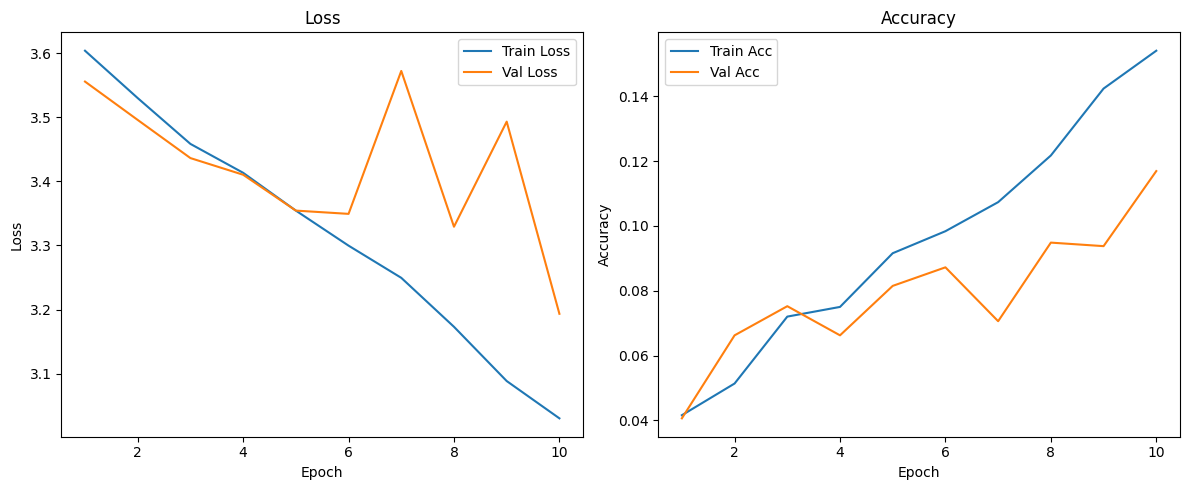

In [ ]:
plot_history(history)

In [ ]:
model.load_state_dict(torch.load("best_petcnn.pth", map_location=CFG.DEVICE))
model.to(CFG.DEVICE)
model.eval()

PetCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=37, bias=True)
)

In [ ]:
show_sample_predictions(
    model=model,
    dataset=test_ds,
    class_names=class_names,
    n=16,
    cols=4,
    save_path="sample_predictions.png",
)

#RESNET

In [ ]:
class PetResNet18(nn.Module):
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True, freeze_backbone=True):
        super().__init__()

        if pretrained:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.backbone = models.resnet18(weights=None)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
model_resnet = PetResNet18(
    num_classes=CFG.NUM_CLASSES,
    pretrained=True,
    freeze_backbone=True
).to(CFG.DEVICE)

criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = torch.optim.Adam(
    model_resnet.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_resnet,
    mode="max",
    factor=0.5,
    patience=2
)

In [ ]:
history_resnet = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc_resnet = 0.0

for epoch in range(1, CFG.EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(
        model_resnet,
        train_loader,
        criterion_resnet,
        optimizer_resnet
    )

    va_loss, va_acc = evaluate(
        model_resnet,
        test_loader,
        criterion_resnet
    )

    history_resnet["train_loss"].append(tr_loss)
    history_resnet["train_acc"].append(tr_acc)
    history_resnet["val_loss"].append(va_loss)
    history_resnet["val_acc"].append(va_acc)

    scheduler_resnet.step(va_acc)

    if va_acc > best_val_acc_resnet:
        best_val_acc_resnet = va_acc
        torch.save(model_resnet.state_dict(), "best_pet_resnet18.pth")

    print(
        f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
        f"train loss: {tr_loss:.4f} | train acc: {tr_acc:.4f} | "
        f"val loss: {va_loss:.4f} | val acc: {va_acc:.4f} | "
        f"best val acc: {best_val_acc_resnet:.4f}"
    )

print("Best ResNet18 val acc:", best_val_acc_resnet)

Epoch 01/10 | train loss: 1.9450 | train acc: 0.5679 | val loss: 0.9558 | val acc: 0.8174 | best val acc: 0.8174
Epoch 02/10 | train loss: 0.7288 | train acc: 0.8549 | val loss: 0.6426 | val acc: 0.8482 | best val acc: 0.8482
Epoch 03/10 | train loss: 0.4992 | train acc: 0.8935 | val loss: 0.5492 | val acc: 0.8542 | best val acc: 0.8542
Epoch 04/10 | train loss: 0.4128 | train acc: 0.9065 | val loss: 0.4872 | val acc: 0.8632 | best val acc: 0.8632
Epoch 05/10 | train loss: 0.3497 | train acc: 0.9171 | val loss: 0.4655 | val acc: 0.8615 | best val acc: 0.8632
Epoch 06/10 | train loss: 0.3074 | train acc: 0.9261 | val loss: 0.4309 | val acc: 0.8768 | best val acc: 0.8768
Epoch 07/10 | train loss: 0.2709 | train acc: 0.9391 | val loss: 0.4459 | val acc: 0.8678 | best val acc: 0.8768
Epoch 08/10 | train loss: 0.2379 | train acc: 0.9394 | val loss: 0.4281 | val acc: 0.8675 | best val acc: 0.8768
Epoch 09/10 | train loss: 0.2220 | train acc: 0.9500 | val loss: 0.4084 | val acc: 0.8735 | best

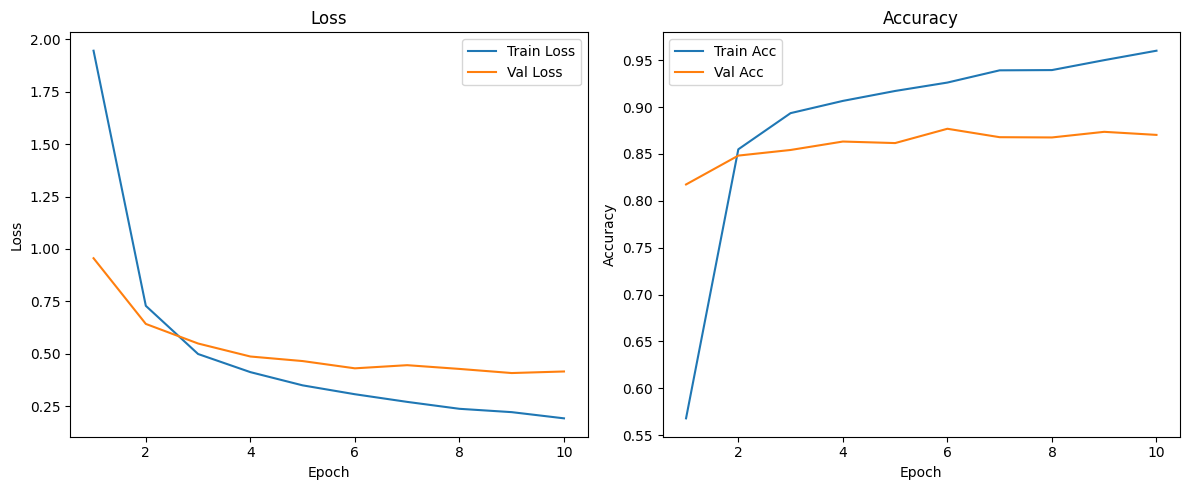

In [ ]:
plot_history(history_resnet)

In [ ]:
model_resnet.load_state_dict(torch.load("best_pet_resnet18.pth", map_location=CFG.DEVICE))
model_resnet.to(CFG.DEVICE)
model_resnet.eval()

PetResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
show_sample_predictions(
    model=model_resnet,
    dataset=test_ds,
    class_names=class_names,
    n=16,
    cols=4,
    save_path="sample_predictions_resnet.png",
)

## Results Comparison

| Model | Training Type | Epochs | Best Validation Accuracy |
|------|---------------|-------|--------------------------|
| Custom CNN | Trained from scratch | 10 | ~11.7% |
| ResNet18 | Transfer Learning (frozen backbone) | 10 | **87.68%** |

### Analysis

- The **custom CNN trained from scratch** struggled to learn complex breed-level visual features, achieving only ~11.7% validation accuracy.
- Using **transfer learning with ResNet18 pretrained on ImageNet** dramatically improved performance.
- Even with the backbone frozen, the model reached **87.68% validation accuracy**, showing the power of pretrained feature extractors on relatively small datasets.

This comparison highlights the effectiveness of **transfer learning for image classification tasks with limited training data**.

## Final Results – Oxford-IIIT Pet Classification

This project compares a **custom CNN trained from scratch** with a **transfer learning approach using ResNet18** on the Oxford-IIIT Pet dataset (37 classes).

### Custom CNN (trained from scratch)

* Architecture: 4 Conv blocks + BatchNorm + AdaptiveAvgPool
* Training epochs: 10
* Best validation accuracy: **~11.7%**

The custom CNN learns basic patterns but struggles to capture complex breed-level visual differences. This is expected given the relatively small dataset and the limited capacity of a shallow CNN.

### ResNet18 (Transfer Learning)

* Pretrained on ImageNet
* Backbone frozen, only the final classification layer trained
* Training epochs: 10
* Best validation accuracy: **87.68%**

Transfer learning dramatically improves performance. Even with the backbone frozen, the pretrained features generalize well to the pet breed classification task.

### Key Takeaways

* **Transfer learning is significantly more effective** than training a CNN from scratch on small datasets.
* Pretrained feature extractors provide strong visual representations that transfer well across domains.
* Fine-tuning the backbone could further improve accuracy beyond the current result.

### Conclusion

For practical applications on moderate-sized datasets like Oxford-IIIT Pet, **pretrained architectures such as ResNet are strongly preferred over scratch CNN models** due to faster convergence and substantially higher accuracy.
